# Projet ML 2026 - Notebook Pipeline

- Mode possible: classification (`Categorie`) ou regression (`Prix_Revente`)
- Dataset: `dataset_ProjetML_2026.csv`
- Objectif: comparer des modeles baseline puis visualiser/exporter les resultats

## 1) Installer et importer les dependances

In [3]:
# IMPORTANT: cet import doit être AVANT sklearn.impute
from sklearn.experimental import enable_iterative_imputer  # noqa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression, BayesianRidge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_absolute_error, mean_squared_error,
    r2_score, silhouette_score,
)
from sklearn.svm import LinearSVC
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 2) Definir les parametres du notebook

In [4]:
DATA_PATH = Path("dataset_ProjetML_2026.csv")
TASK = "classification"   # "classification" ou "regression"
TARGET = "Categorie"      # classification: "Categorie" ; regression: "Prix_Revente"

# Exigence cahier des charges: split fixe 70/15/15
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_STATE = 42
USE_TEXT_FEATURE = True

NA_VALUES = ["", " ", "NA", "N/A", "null", "None", "non mesure", "non mesure kg"]
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Task={TASK}, Target={TARGET}, Data={DATA_PATH}")
print(f"Ratios -> train={TRAIN_RATIO}, val={VAL_RATIO}, test={TEST_RATIO}")

Task=classification, Target=Categorie, Data=dataset_ProjetML_2026.csv
Ratios -> train=0.7, val=0.15, test=0.15


## 3) Charger les donnees d'entree

In [5]:
df = pd.read_csv(DATA_PATH, na_values=NA_VALUES)
print(f"Shape: {df.shape}")
print(f"Colonnes: {df.columns.tolist()}")
display(df.head(3))

print("\nValeurs manquantes (%)")
display((df.isnull().sum() / len(df) * 100).round(2).to_frame("% NaN"))

Shape: (10500, 9)
Colonnes: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte']


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...



Valeurs manquantes (%)


,% NaN
Poids,9.80
Volume,5.14
Conductivite,9.69
Opacite,9.86
Rigidite,5.31
Prix_Revente,5.10
Categorie,4.90
Source,5.10
Rapport_Collecte,0.00


In [6]:
# Resume statistique des variables numeriques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    display(df[num_cols].describe().T)
else:
    print("Aucune colonne numerique detectee.")

,count,mean,std,min,25%,50%,75%,max
Poids,9471.0,77.796501,127.847433,-99.000000,19.751538,39.193029,130.497561,2334.218831
Volume,9960.0,144.408079,136.384216,-26.807712,44.436897,88.084217,240.200023,554.106969
Conductivite,9483.0,0.207674,0.378934,0.000000,0.000000,0.000000,0.000000,0.999375
Opacite,9465.0,1.160388,5.492723,0.000037,0.196410,0.553484,1.000000,55.000000
Rigidite,9942.0,5.886643,3.087225,1.000000,3.000000,5.000000,9.000000,10.000000
Prix_Revente,9964.0,58.587857,720.059089,-50.000000,1.393623,4.135356,6.781634,9999.000000


Distribution de la cible:


,count
Categorie,
Plastique,2795
Verre,2586
Papier,2318
Métal,2287
NaN,514


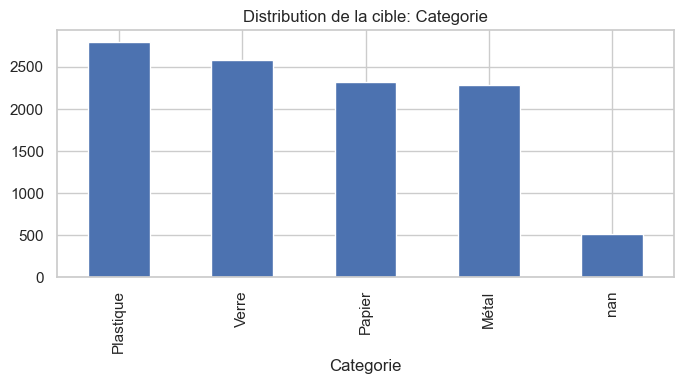

In [7]:
# Distribution de la cible
if TARGET in df.columns:
    print("Distribution de la cible:")
    display(df[TARGET].value_counts(dropna=False).to_frame("count"))
    plt.figure(figsize=(7, 4))
    df[TARGET].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribution de la cible: {TARGET}")
    plt.tight_layout()
    plt.show()

## 3.1) MODULE 1 — Analyse des valeurs manquantes et comparaison des strategies d'imputation

Objectif: identifier le mecanisme de manquance (MCAR/MAR/MNAR) et comparer Mediane vs KNNImputer vs IterativeImputer.

In [8]:
# --- 1. Identifier les colonnes avec valeurs manquantes ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
missing_stats = df[num_cols].isnull().sum()
missing_pct = (missing_stats / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "nb_manquants": missing_stats,
    "pourcentage": missing_pct
}).query("nb_manquants > 0").sort_values("pourcentage", ascending=False)

print("=== Valeurs manquantes par colonne ===")
display(missing_df)

=== Valeurs manquantes par colonne ===


,nb_manquants,pourcentage
Opacite,1035,9.86
Poids,1029,9.80
Conductivite,1017,9.69
Rigidite,558,5.31
Volume,540,5.14
Prix_Revente,536,5.10


In [9]:
# --- 2. Diagnostic MCAR / MAR / MNAR ---
col_test = "Poids"
df_test = df[[col_test, "Conductivite", "Opacite", "Rigidite", "Prix_Revente"]].copy()

print(f"=== Diagnostic du mecanisme de manquance pour '{col_test}' ===\n")
df_test["is_missing"] = df_test[col_test].isnull().astype(int)

print("Correlation entre manquance et autres variables numeriques :")
for col in ["Conductivite", "Opacite", "Rigidite", "Prix_Revente"]:
    col_clean = df_test[[col, "is_missing"]].dropna()
    r, p = stats.pointbiserialr(col_clean["is_missing"], col_clean[col])
    sig = "** MAR possible **" if p < 0.05 else "non significatif"
    print(f"  {col}: r={r:.3f}, p={p:.4f}  -> {sig}")

print("\nConclusion :")
print("  - Si correlations significatives -> MAR (Missing At Random)")
print("  - Si pas de correlation -> MCAR (Missing Completely At Random)")
print("  - Si lie a la valeur manquante elle-meme -> MNAR (impossible a tester directement)")

=== Diagnostic du mecanisme de manquance pour 'Poids' ===

Correlation entre manquance et autres variables numeriques :
  Conductivite: r=0.035, p=0.0007  -> ** MAR possible **
  Opacite: r=-0.009, p=0.3669  -> non significatif
  Rigidite: r=-0.005, p=0.6412  -> non significatif
  Prix_Revente: r=-0.019, p=0.0570  -> non significatif

Conclusion :
  - Si correlations significatives -> MAR (Missing At Random)
  - Si pas de correlation -> MCAR (Missing Completely At Random)
  - Si lie a la valeur manquante elle-meme -> MNAR (impossible a tester directement)


In [10]:
# --- 3. Comparaison des 3 strategies d'imputation (distributions) ---
cols_to_impute = missing_df.index.tolist()
df_num = df[cols_to_impute].copy()

imp_median = SimpleImputer(strategy="median")
df_median = pd.DataFrame(imp_median.fit_transform(df_num), columns=cols_to_impute)

imp_knn = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(imp_knn.fit_transform(df_num), columns=cols_to_impute)

imp_iter = IterativeImputer(estimator=BayesianRidge(), random_state=RANDOM_STATE, max_iter=10)
df_iter = pd.DataFrame(imp_iter.fit_transform(df_num), columns=cols_to_impute)

print(f"Imputation terminee pour les 3 strategies. Colonnes : {cols_to_impute}")

Imputation terminee pour les 3 strategies. Colonnes : ['Opacite', 'Poids', 'Conductivite', 'Rigidite', 'Volume', 'Prix_Revente']


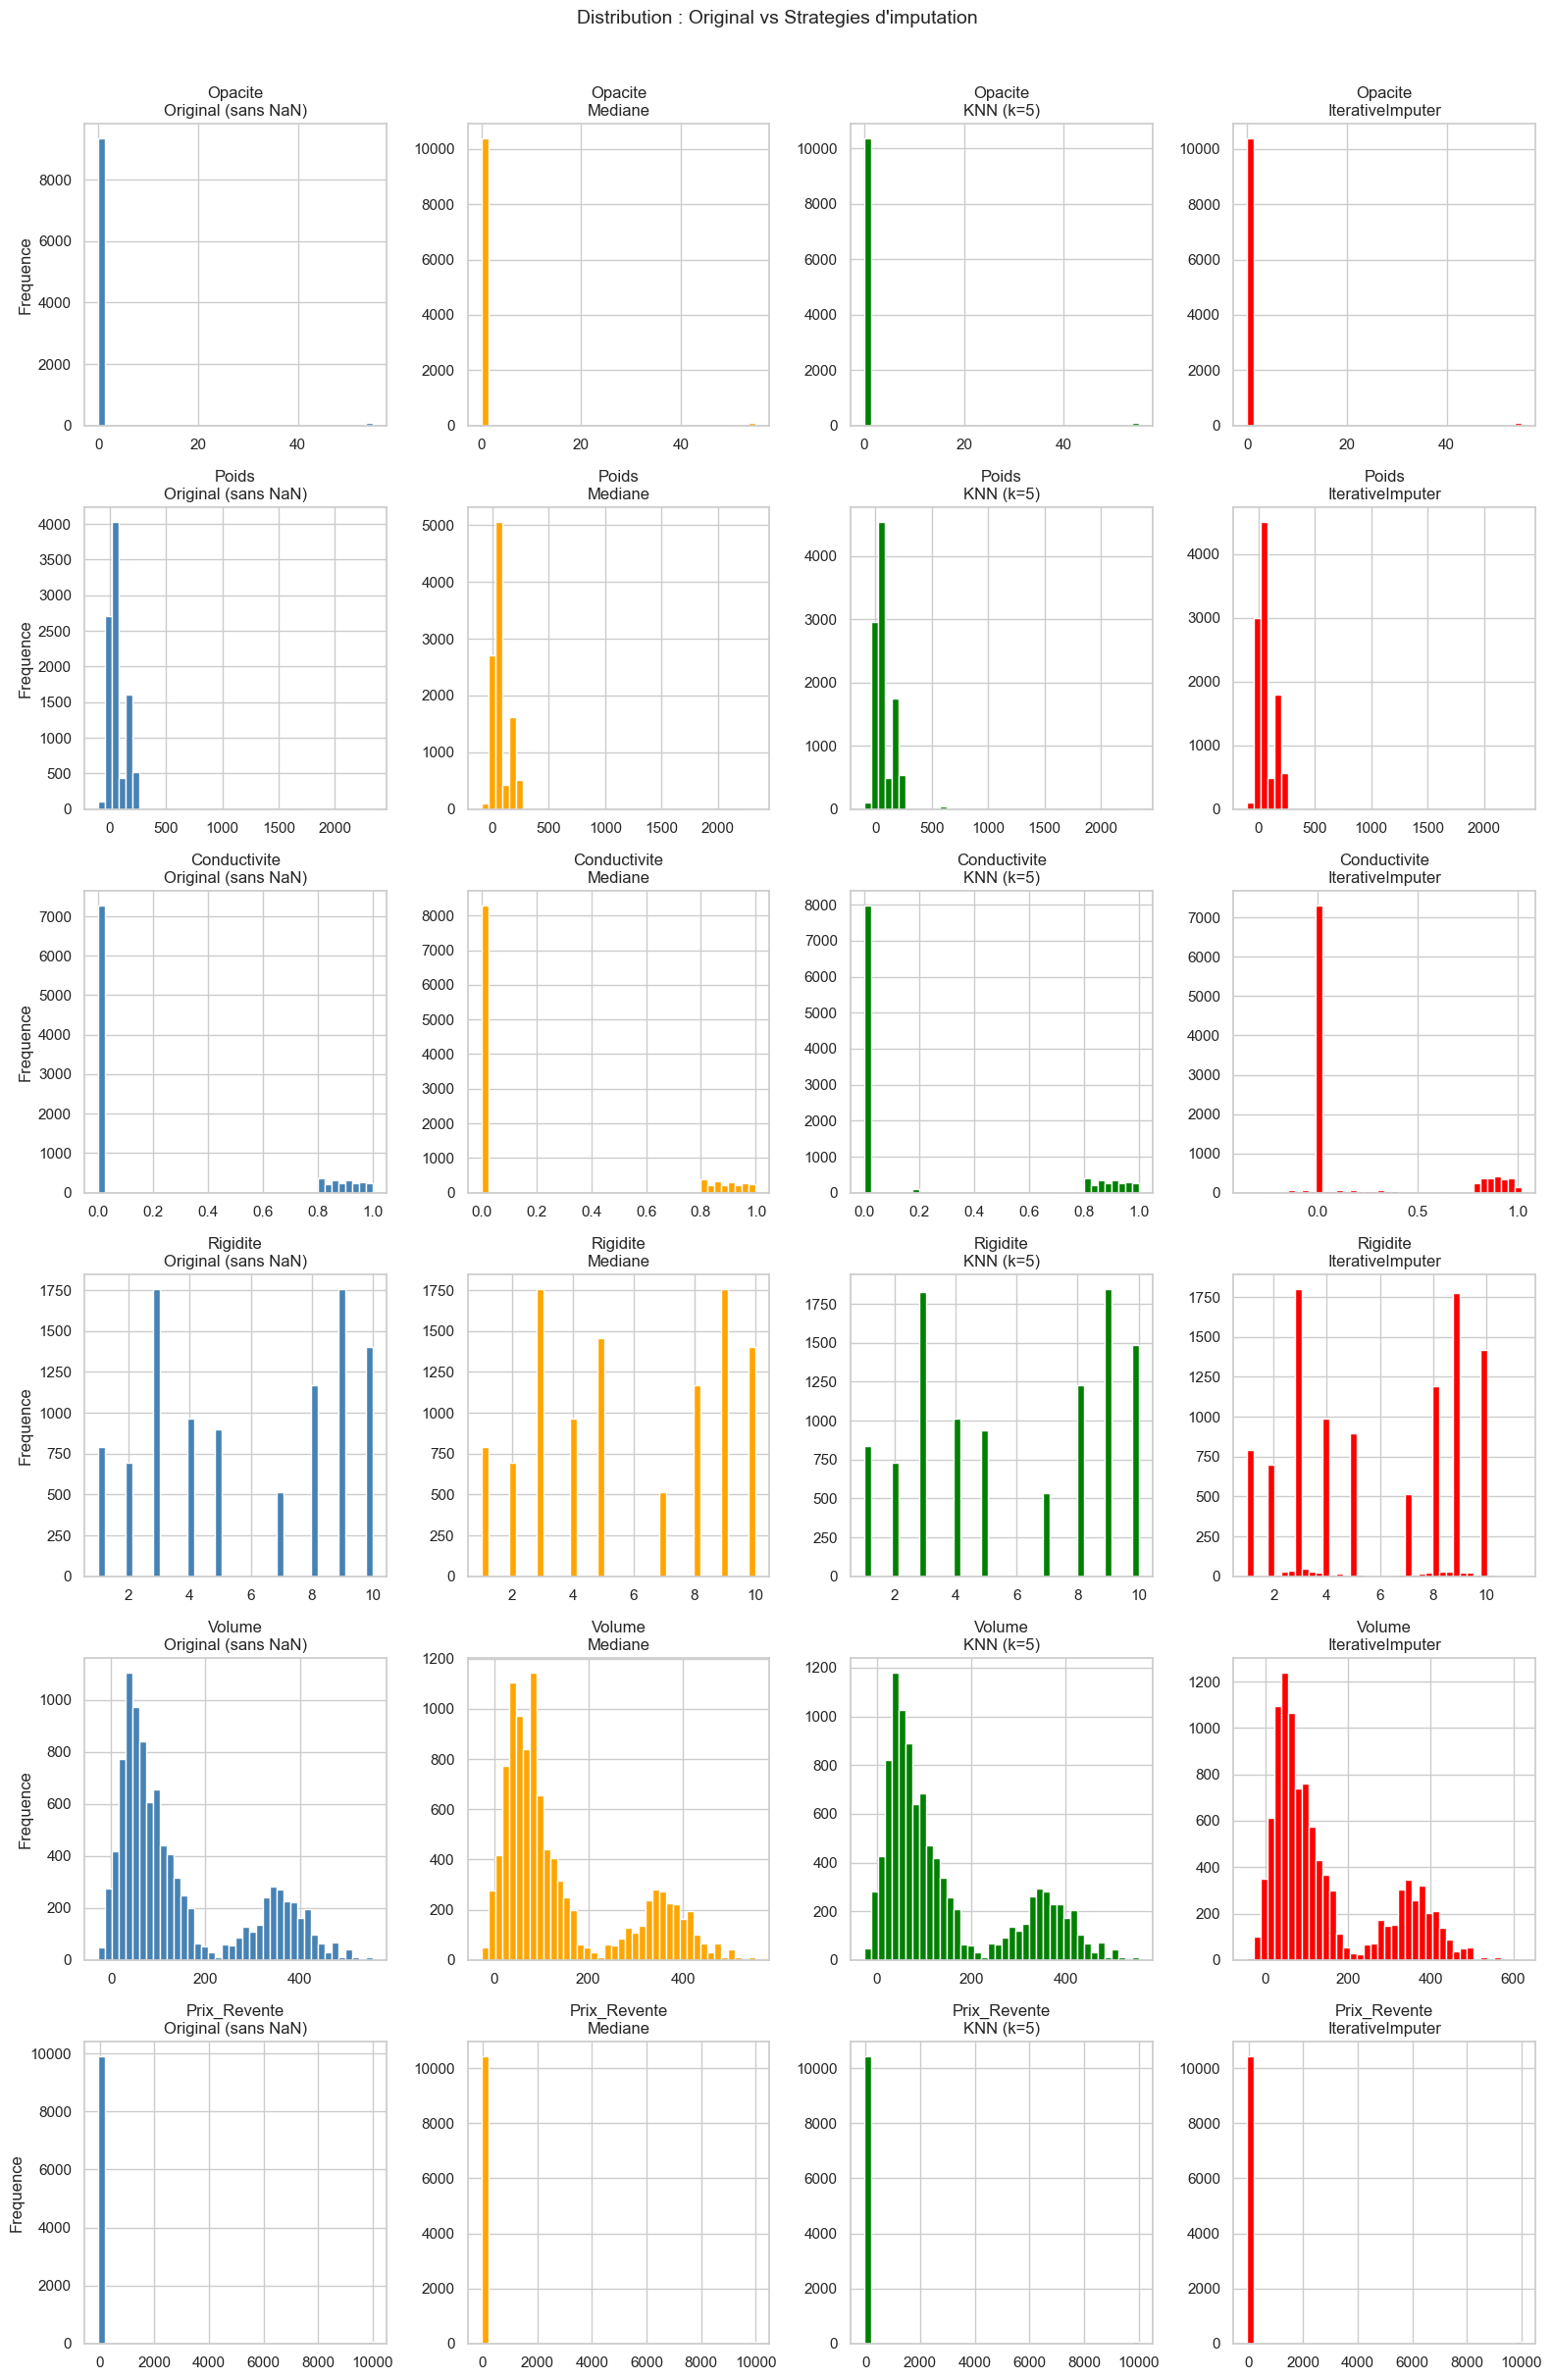

In [11]:
# --- 4. Visualisation : distributions avant/apres imputation ---
strategies = {"Mediane": df_median, "KNN (k=5)": df_knn, "IterativeImputer": df_iter}

fig, axes = plt.subplots(len(cols_to_impute), 4, figsize=(16, 4 * len(cols_to_impute)))
if len(cols_to_impute) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(cols_to_impute):
    axes[i, 0].hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{col}\nOriginal (sans NaN)")
    axes[i, 0].set_ylabel("Frequence")
    for j, (strat_name, df_strat) in enumerate(strategies.items()):
        axes[i, j+1].hist(df_strat[col], bins=40, color=["orange", "green", "red"][j], edgecolor="white")
        axes[i, j+1].set_title(f"{col}\n{strat_name}")

plt.suptitle("Distribution : Original vs Strategies d'imputation", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "imputation_comparison_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# --- 5. Tableau recapitulatif : moyenne et ecart-type apres imputation ---
rows_stats = []
for col in cols_to_impute:
    rows_stats.append({"Colonne": col, "Strategie": "Original",
                       "Moyenne": round(df[col].mean(), 4), "Ecart-type": round(df[col].std(), 4)})
    for strat_name, df_strat in strategies.items():
        rows_stats.append({"Colonne": col, "Strategie": strat_name,
                           "Moyenne": round(df_strat[col].mean(), 4), "Ecart-type": round(df_strat[col].std(), 4)})
display(pd.DataFrame(rows_stats))

,Colonne,Strategie,Moyenne,Ecart-type
0,Opacite,Original,1.1604,5.4927
1,Opacite,Mediane,1.1006,5.2181
2,Opacite,KNN (k=5),1.1793,5.4758
3,Opacite,IterativeImputer,1.1613,5.2152
4,Poids,Original,77.7965,127.8474
5,Poids,Mediane,74.0134,121.9621
6,Poids,KNN (k=5),79.5253,128.5971
7,Poids,IterativeImputer,77.0924,123.2498
8,Conductivite,Original,0.2077,0.3789
9,Conductivite,Mediane,0.1876,0.3653


In [13]:
# --- 6. Choix final et application au dataframe principal ---
print("""
=== CHOIX DE LA STRATEGIE D'IMPUTATION ===

- Mediane         : Simple, robuste aux outliers. Bon pour distributions asymetriques (MCAR).
- KNNImputer      : Exploite la similarite entre voisins. Meilleur si variables correlees (MAR).
- IterativeImputer: Modelise chaque variable via les autres (MICE). Preserve les correlations.

-> Choix retenu : KNNImputer (k=5) si MAR confirme, Mediane en fallback pour MCAR.
""")

imp_final = KNNImputer(n_neighbors=5)
df_num_imputed = pd.DataFrame(
    imp_final.fit_transform(df[cols_to_impute]),
    columns=cols_to_impute,
    index=df.index
)
df[cols_to_impute] = df_num_imputed
print(f"NaN restants apres imputation finale : {df[cols_to_impute].isnull().sum().sum()}")


=== CHOIX DE LA STRATEGIE D'IMPUTATION ===

- Mediane         : Simple, robuste aux outliers. Bon pour distributions asymetriques (MCAR).
- KNNImputer      : Exploite la similarite entre voisins. Meilleur si variables correlees (MAR).
- IterativeImputer: Modelise chaque variable via les autres (MICE). Preserve les correlations.

-> Choix retenu : KNNImputer (k=5) si MAR confirme, Mediane en fallback pour MCAR.

NaN restants apres imputation finale : 0


## 3.2) Detection et traitement des outliers

Objectif: quantifier les outliers puis appliquer un caping (winsorization) sur les variables numeriques.

,feature,outlier_rate_%,low,high
2,Conductivite,23.933333,0.000000,0.000000
5,Prix_Revente,17.466667,-6.454267,14.723174
0,Poids,1.209524,-144.225157,293.665396
3,Opacite,1.209524,-1.001405,2.200843
1,Volume,0.114286,-249.207793,533.844712
4,Rigidite,0.000000,-6.000000,18.000000


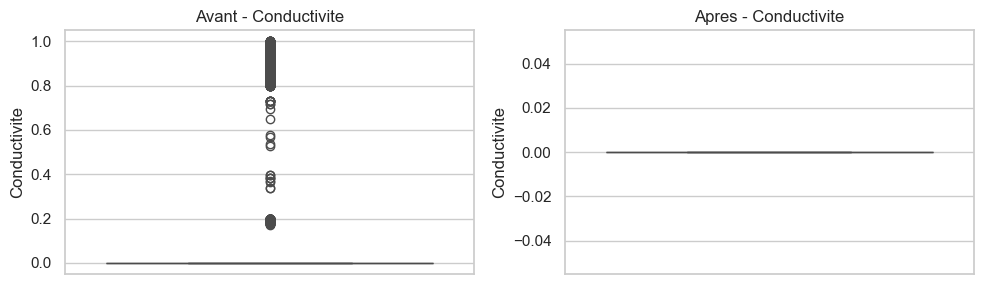

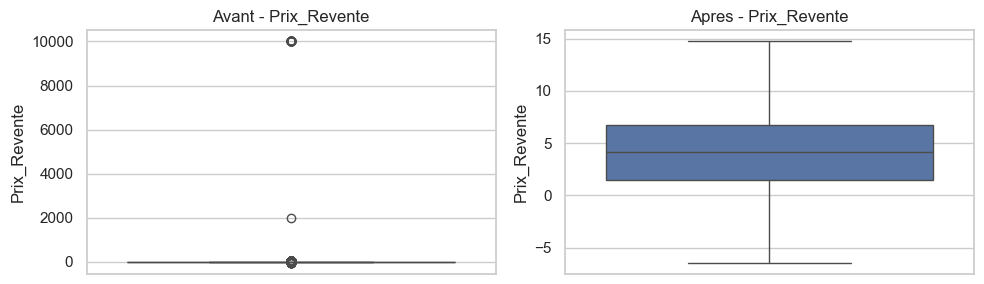

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def iqr_outlier_report(df_input, cols):
    rows = []
    for c in cols:
        s = df_input[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out_rate = ((df_input[c] < low) | (df_input[c] > high)).mean() * 100
        rows.append({"feature": c, "outlier_rate_%": out_rate, "low": low, "high": high})
    return pd.DataFrame(rows).sort_values("outlier_rate_%", ascending=False)

outlier_report = iqr_outlier_report(df, num_cols)
display(outlier_report)

def winsorize_iqr(df_input, cols):
    out = df_input.copy()
    for c in cols:
        s = out[c]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out[c] = s.clip(lower=low, upper=high)
    return out

df_outlier_capped = winsorize_iqr(df, num_cols)

# Visualisation: top 2 variables les plus outliers
for c in outlier_report.head(2)["feature"].tolist():
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.boxplot(y=df[c], ax=axes[0])
    axes[0].set_title(f"Avant - {c}")
    sns.boxplot(y=df_outlier_capped[c], ax=axes[1])
    axes[1].set_title(f"Apres - {c}")
    plt.tight_layout()
    plt.show()

## 4) Fonctions utilitaires reutilisables

In [15]:
def split_train_val_test(X, y, stratify=False):
    strat = y if stratify else None
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=(1 - TRAIN_RATIO), random_state=RANDOM_STATE, stratify=strat)
    strat_tmp = y_tmp if stratify else None
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE, stratify=strat_tmp)
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_preprocessor(df_input, target_col, use_text=True):
    text_candidates = ["Rapport_Collecte", "Rapport"]
    text_col = None
    if use_text:
        for col in text_candidates:
            if col in df_input.columns:
                text_col = col
                break

    feature_cols = [c for c in df_input.columns if c != target_col]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_input[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols and c != text_col]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformers = [
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols),
    ]

    if text_col:
        text_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="")),
            ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
            ("tfidf", TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
        ])
        transformers.append(("txt", text_pipe, [text_col]))

    return ColumnTransformer(transformers=transformers)

print("Fonctions utilitaires definies.")

Fonctions utilitaires definies.


### 4.1) Fonction d'entrainement et d'evaluation : classification

In [16]:
def train_and_evaluate_classification(df_input, target_col):
    data = df_input.dropna(subset=[target_col]).copy()
    X = data.drop(columns=[target_col])
    y = data[target_col].astype(str)
    preprocessor = build_preprocessor(data, target_col, USE_TEXT_FEATURE)
    models = {
        "logreg": LogisticRegression(max_iter=2000),
        "rf": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    }
    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=True)
    rows, artifacts = [], {}
    for name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        pred_val  = pipe.predict(X_val)
        pred_test = pipe.predict(X_test)
        rows.append({"model": name,
                     "f1_val": f1_score(y_val, pred_val, average="macro"),
                     "accuracy_test": accuracy_score(y_test, pred_test),
                     "f1_macro_test": f1_score(y_test, pred_test, average="macro")})
        artifacts[name] = {"pipeline": pipe, "y_test": y_test, "pred": pred_test,
                           "confusion": confusion_matrix(y_test, pred_test),
                           "report": classification_report(y_test, pred_test)}
    return pd.DataFrame(rows).sort_values("f1_val", ascending=False).reset_index(drop=True), artifacts

### 4.2) Fonction d'entrainement et d'evaluation : regression

In [17]:
def train_and_evaluate_regression(df_input, target_col):
    data = df_input.dropna(subset=[target_col]).copy()
    X = data.drop(columns=[target_col])
    y = pd.to_numeric(data[target_col], errors="coerce")
    mask = y.notna()
    X, y, data = X.loc[mask], y.loc[mask], data.loc[mask]
    preprocessor = build_preprocessor(data, target_col, USE_TEXT_FEATURE)
    models = {
        "linreg": LinearRegression(),
        "rf_reg": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    }
    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=False)
    rows, artifacts = [], {}
    for name, model in models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_train, y_train)
        pred_val  = pipe.predict(X_val)
        pred_test = pipe.predict(X_test)
        rows.append({"model": name,
                     "rmse_val": float(np.sqrt(mean_squared_error(y_val, pred_val))),
                     "MAE_test": mean_absolute_error(y_test, pred_test),
                     "RMSE_test": float(np.sqrt(mean_squared_error(y_test, pred_test))),
                     "R2_test": r2_score(y_test, pred_test)})
        artifacts[name] = {"pipeline": pipe, "y_test": y_test, "pred": pred_test}
    return pd.DataFrame(rows).sort_values("rmse_val", ascending=True).reset_index(drop=True), artifacts

## 5) MODULE 1 (suite) — Comparaison des imputeurs sur la performance ML

Objectif: mesurer l'impact de chaque strategie d'imputation sur le F1 du modele.

In [18]:
def compare_imputers(df_input, target_col):
    data = df_input.dropna(subset=[target_col]).copy()
    X = data.drop(columns=[target_col])
    y = data[target_col].astype(str) if TASK == "classification" else pd.to_numeric(data[target_col], errors="coerce")
    if TASK == "regression":
        mask = y.notna()
        X, y, data = X.loc[mask], y.loc[mask], data.loc[mask]

    imputers = {
        "median":    SimpleImputer(strategy="median"),
        "knn":       KNNImputer(n_neighbors=5),
        "iterative": IterativeImputer(random_state=RANDOM_STATE, max_iter=10),
    }

    rows = []
    for imputer_name, imputer in imputers.items():
        text_col = None
        if USE_TEXT_FEATURE:
            for c in ["Rapport_Collecte", "Rapport"]:
                if c in data.columns:
                    text_col = c
                    break

        feature_cols    = [c for c in data.columns if c != target_col]
        numeric_cols    = [c for c in feature_cols if pd.api.types.is_numeric_dtype(data[c])]
        categorical_cols = [c for c in feature_cols if c not in numeric_cols and c != text_col]

        num_pipe = Pipeline([("imputer", imputer), ("scaler", StandardScaler())])
        cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                             ("onehot", OneHotEncoder(handle_unknown="ignore"))])
        transformers = [("num", num_pipe, numeric_cols), ("cat", cat_pipe, categorical_cols)]
        if text_col:
            text_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="")),
                ("flatten", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
                ("tfidf", TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
            ])
            transformers.append(("txt", text_pipe, [text_col]))

        preprocessor = ColumnTransformer(transformers=transformers)

        if TASK == "classification":
            model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
            X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=True)
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            pipe.fit(X_train, y_train)
            rows.append({"imputer": imputer_name,
                         "f1_val":  f1_score(y_val,  pipe.predict(X_val),  average="macro"),
                         "f1_test": f1_score(y_test, pipe.predict(X_test), average="macro")})
        else:
            model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
            X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y, stratify=False)
            pipe = Pipeline([("prep", preprocessor), ("model", model)])
            pipe.fit(X_train, y_train)
            rows.append({"imputer": imputer_name,
                         "rmse_val":  float(np.sqrt(mean_squared_error(y_val,  pipe.predict(X_val)))),
                         "rmse_test": float(np.sqrt(mean_squared_error(y_test, pipe.predict(X_test))))})
    return pd.DataFrame(rows)


imputation_results = compare_imputers(df, TARGET)
display(imputation_results)

,imputer,f1_val,f1_test
0,median,1.0,1.0
1,knn,1.0,1.0
2,iterative,1.0,1.0


## 6) MODULE 2 — Executer le pipeline principal (Classification / Regression)

In [19]:
if TARGET not in df.columns:
    raise ValueError(f"La cible '{TARGET}' est absente du dataset.")
if TASK not in {"classification", "regression"}:
    raise ValueError("TASK doit etre 'classification' ou 'regression'.")

print(f"Execution prete. TASK={TASK} | TARGET={TARGET}")

Execution prete. TASK=classification | TARGET=Categorie


In [20]:
if TASK == "classification":
    results_df, artifacts = train_and_evaluate_classification(df, TARGET)
else:
    results_df, artifacts = train_and_evaluate_regression(df, TARGET)

best_model_name = results_df.iloc[0]["model"]
best_artifact   = artifacts[best_model_name]
print(f"Meilleur modele: {best_model_name}")
display(results_df)

Meilleur modele: logreg


,model,f1_val,accuracy_test,f1_macro_test
0,logreg,1.0,1.0,1.0
1,rf,1.0,1.0,1.0


## 7) Afficher les resultats intermediaires

In [21]:
if TASK == "classification":
    print("Classification report du meilleur modele:\n")
    print(best_artifact["report"])
    display(pd.DataFrame(best_artifact["confusion"]))
else:
    y_true = pd.Series(best_artifact["y_test"]).reset_index(drop=True)
    y_pred = pd.Series(best_artifact["pred"]).reset_index(drop=True)
    control_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    control_df["abs_error"] = (control_df["y_true"] - control_df["y_pred"]).abs()
    display(control_df.head(10))
    print("Erreur absolue moyenne:", control_df["abs_error"].mean())

Classification report du meilleur modele:

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



,0,1,2,3
0,343,0,0,0
1,0,348,0,0
2,0,0,419,0
3,0,0,0,388


## 8) Visualiser les resultats finaux

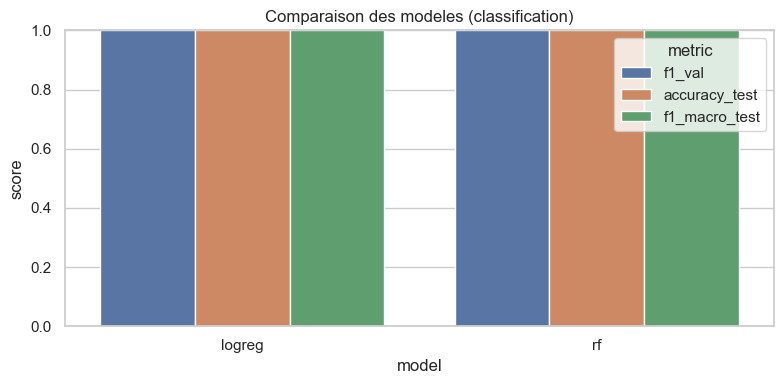

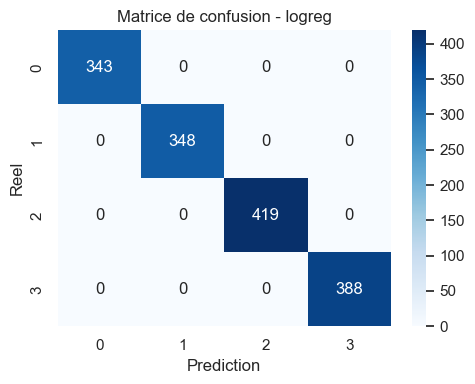

In [22]:
plt.figure(figsize=(8, 4))
if TASK == "classification":
    plot_df = results_df.melt(id_vars="model",
                              value_vars=["f1_val", "accuracy_test", "f1_macro_test"],
                              var_name="metric", value_name="score")
    sns.barplot(data=plot_df, x="model", y="score", hue="metric")
    plt.ylim(0, 1)
    plt.title("Comparaison des modeles (classification)")
else:
    plot_df = results_df.melt(id_vars="model",
                              value_vars=["rmse_val", "MAE_test", "RMSE_test", "R2_test"],
                              var_name="metric", value_name="value")
    sns.barplot(data=plot_df, x="model", y="value", hue="metric")
    plt.title("Comparaison des modeles (regression)")
plt.tight_layout()
plt.show()

if TASK == "classification":
    plt.figure(figsize=(5, 4))
    sns.heatmap(best_artifact["confusion"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matrice de confusion - {best_model_name}")
    plt.xlabel("Prediction")
    plt.ylabel("Reel")
    plt.tight_layout()
    plt.show()

## 9) Exporter les sorties (fichiers/rapports)

In [23]:
metrics_path = OUTPUT_DIR / f"metrics_{TASK}_{TARGET}.csv"
results_df.to_csv(metrics_path, index=False)
print("Metrics exportees:", metrics_path)

if TASK == "classification":
    report_path = OUTPUT_DIR / f"classification_report_{best_model_name}.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(best_artifact["report"])
    print("Rapport exporte:", report_path)

plot_path = OUTPUT_DIR / f"plot_resume_{TASK}_{TARGET}.png"
plt.figure(figsize=(7, 4))
if TASK == "classification":
    sns.barplot(data=results_df.melt(id_vars="model",
                                     value_vars=["f1_val", "accuracy_test", "f1_macro_test"],
                                     var_name="metric", value_name="score"),
                x="model", y="score", hue="metric")
    plt.ylim(0, 1)
else:
    sns.barplot(data=results_df.melt(id_vars="model",
                                     value_vars=["rmse_val", "MAE_test", "RMSE_test", "R2_test"],
                                     var_name="metric", value_name="value"),
                x="model", y="value", hue="metric")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.close()
print("Graphique exporte:", plot_path)

Metrics exportees: outputs\metrics_classification_Categorie.csv
Rapport exporte: outputs\classification_report_logreg.txt
Graphique exporte: outputs\plot_resume_classification_Categorie.png


## 10) MODULE 3 — Clustering non supervise (K-Means + Elbow + PCA 2D)

Objectif: ignorer les labels et segmenter les dechets pour decouvrir des sous-groupes de materiaux.

,k,inertia,silhouette
0,2,42879.047661,0.545071
1,3,30307.365680,0.702958
2,4,20021.770152,0.725757
3,5,10050.978314,0.756777
4,6,5094.234623,0.769012
5,7,4284.016725,0.775192
6,8,3617.875673,0.589527
7,9,3193.439092,0.504831
8,10,2964.113365,0.414522


k retenu (silhouette max): 7


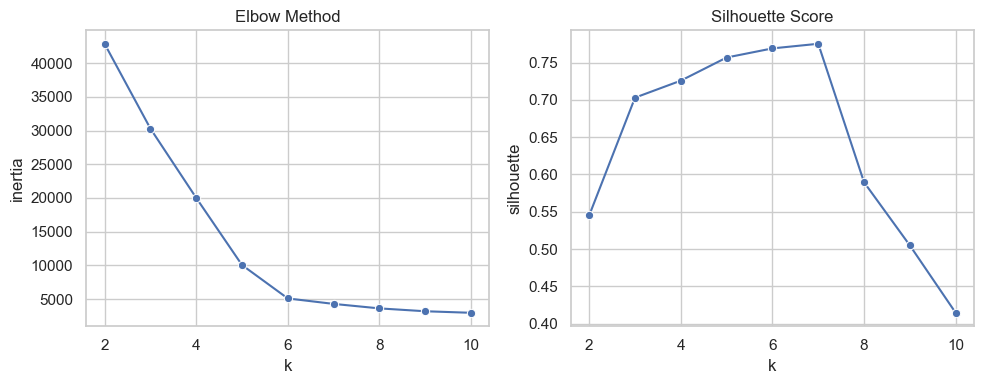

In [36]:
# Preparer les donnees numeriques pour le clustering
cluster_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cluster = df[cluster_num_cols].copy()
X_cluster = X_cluster.fillna(X_cluster.median(numeric_only=True))
X_cluster = StandardScaler().fit_transform(X_cluster)

# Elbow Method + Silhouette score
ks = list(range(2, 11))
inertias, sil_scores = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

elbow_df = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": sil_scores})
display(elbow_df)

best_k = int(elbow_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("k retenu (silhouette max):", best_k)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.lineplot(data=elbow_df, x="k", y="inertia", marker="o")
plt.title("Elbow Method")
plt.subplot(1, 2, 2)
sns.lineplot(data=elbow_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette Score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clustering_elbow.png", dpi=150)
plt.show()

Variance expliquee : PC1=37.1%  PC2=20.5%  Total=57.7%


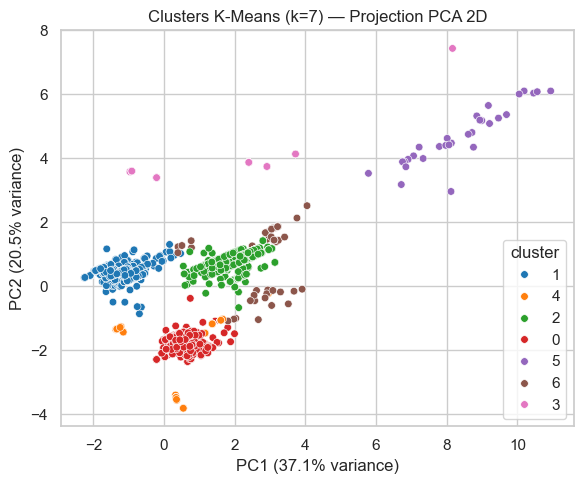

In [25]:
# K-Means final + PCA 2D
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)
explained = pca.explained_variance_ratio_ * 100
print(f"Variance expliquee : PC1={explained[0]:.1f}%  PC2={explained[1]:.1f}%  Total={sum(explained):.1f}%")

pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "cluster": cluster_labels.astype(str)})

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", s=30, palette="tab10")
plt.title(f"Clusters K-Means (k={best_k}) — Projection PCA 2D")
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clustering_pca2d.png", dpi=150)
plt.show()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
Cluster,,,,,,
0,-0.149,-0.171,1.821,-0.034,0.860,-0.055
1,-0.440,-0.714,-0.548,-0.088,-0.906,-0.077
2,0.750,1.579,-0.533,-0.181,1.042,-0.072
3,0.619,0.903,-0.551,-0.150,0.259,14.169
4,0.048,0.184,0.015,9.829,0.247,-0.071
5,13.651,1.576,-0.517,0.130,1.086,-0.072
6,3.831,0.963,-0.072,-0.161,0.713,-0.069


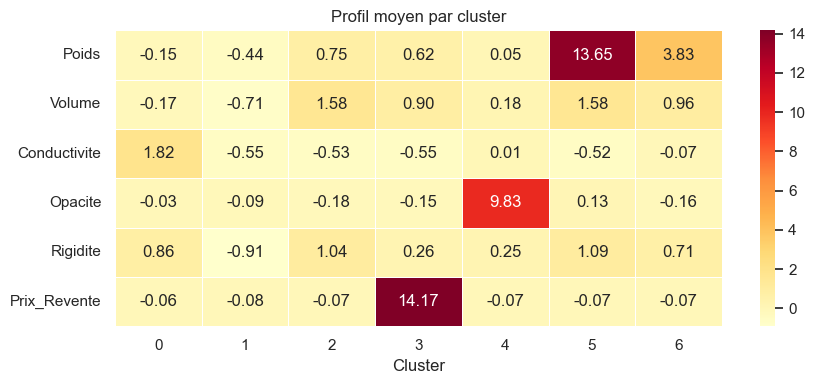

In [26]:
# Profil moyen de chaque cluster
df_cluster_profile = pd.DataFrame(X_cluster, columns=cluster_num_cols)
df_cluster_profile["Cluster"] = cluster_labels
df_profile = df_cluster_profile.groupby("Cluster")[cluster_num_cols].mean().round(3)
display(df_profile)

plt.figure(figsize=(9, 4))
sns.heatmap(df_profile.T, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Profil moyen par cluster")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "clustering_profiles.png", dpi=150)
plt.show()

## 11) MODULE 4 — Comparaison NLP (BoW, TF-IDF, Word2Vec, FastText)

Objectif: comparer plusieurs representations textuelles pour predire la categorie a partir de la description.

In [31]:
# ============================================================
# MODULE 4 — Prétraitement NLP
# Tokenisation + Stopwords français + Stemming
# ZONE ROUGE : ce bloc doit être écrit par l'étudiant
# ============================================================

import re
import unicodedata
from nltk.stem.snowball import FrenchStemmer
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# --- Stopwords français + domaine métier ---
STOPWORDS_FR = set(stopwords.words("french"))
STOPWORDS_DOMAINE = {
    "lot", "collecte", "site", "materiau", "materiel", "type",
    "provenance", "volume", "poids", "kg", "litre", "unite",
    "usine", "centre", "tri", "dechets", "dechet", "rapport",
    "reference", "ref", "non", "renseigne", "mesure"
}
STOPWORDS_TOUS = STOPWORDS_FR | STOPWORDS_DOMAINE

stemmer = FrenchStemmer()

def preprocess_text(text: str) -> str:
    """
    Pipeline NLP :
    1. Minuscules
    2. Suppression accents
    3. Suppression ponctuation/chiffres
    4. Tokenisation (split)
    5. Suppression stopwords
    6. Stemming (FrenchStemmer)
    """
    if not isinstance(text, str):
        return ""

    # 1. Minuscules
    text = text.lower()

    # 2. Suppression des accents
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")

    # 3. Suppression ponctuation et chiffres
    text = re.sub(r"[^a-z\s]", " ", text)

    # 4. Tokenisation
    tokens = text.split()

    # 5. Suppression stopwords (longueur > 2)
    tokens = [t for t in tokens if t not in STOPWORDS_TOUS and len(t) > 2]

    # 6. Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)


# Test rapide
exemple = "Lot de plastique récupéré à l'Usine A. Volume 64.7 L, poids non mesuré."
print("Original  :", exemple)
print("Traité    :", preprocess_text(exemple))

Original  : Lot de plastique récupéré à l'Usine A. Volume 64.7 L, poids non mesuré.
Traité    : plastiqu recuper


In [32]:
# --- Appliquer le prétraitement sur la colonne texte ---

text_col = "Rapport_Collecte" if "Rapport_Collecte" in df.columns else "Rapport"

nlp_data = df[[text_col, "Categorie"]].dropna().copy()
nlp_data["texte_clean"] = nlp_data[text_col].apply(preprocess_text)

print(f"Données NLP : {len(nlp_data)} lignes")
print("\nExemple avant/après :")
for i in range(3):
    print(f"\n[{i}] AVANT : {nlp_data[text_col].iloc[i][:80]}")
    print(f"    APRÈS : {nlp_data['texte_clean'].iloc[i][:80]}")

Données NLP : 9986 lignes

Exemple avant/après :

[0] AVANT : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volum
    APRÈS : papi recuper leg moyen soupl conducteur aspect tre opaqu bon etat general

[1] AVANT : Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, ri
    APRÈS : plastiqu aspect indetermine rigidit moyen aucun trac metal

[2] AVANT : Bris de verre ou contenants en provenance de l'Usine B. Masse non mesuré kg. Mat
    APRÈS : bris verr conten mass dens rigidit eleve transparent partiel leger contamin obse


In [33]:
# ============================================================
# MODULE 4 — Comparaison vectorisations x classifieurs
# BoW, TF-IDF, Word2Vec, FastText  x  NB, LinearSVC, LogReg, RF
# ============================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MaxAbsScaler

X_text = nlp_data["texte_clean"].astype(str)
y_text = nlp_data["Categorie"].astype(str)

X_train_t, X_val_t, X_test_t, y_train_t, y_val_t, y_test_t = split_train_val_test(
    X_text, y_text, stratify=True
)

# Classifieurs à tester
classifieurs = {
    "NaiveBayes": MultinomialNB(),
    "LinearSVC":  LinearSVC(max_iter=2000),
    "LogReg":     LogisticRegression(max_iter=2000),
    "RF":         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

nlp_rows = []

# --- 1. BoW ---
bow_vect = CountVectorizer(max_features=8000, ngram_range=(1, 2))
X_tr_bow = bow_vect.fit_transform(X_train_t)
X_va_bow = bow_vect.transform(X_val_t)
X_te_bow = bow_vect.transform(X_test_t)

for clf_name, clf in classifieurs.items():
    try:
        clf.fit(X_tr_bow, y_train_t)
        nlp_rows.append({
            "vectorisation": "BoW",
            "classifieur": clf_name,
            "f1_val":  f1_score(y_val_t,  clf.predict(X_va_bow), average="macro"),
            "f1_test": f1_score(y_test_t, clf.predict(X_te_bow), average="macro"),
        })
    except Exception as e:
        print(f"BoW + {clf_name} erreur: {e}")

# --- 2. TF-IDF ---
tfidf_vect = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_tr_tfidf = tfidf_vect.fit_transform(X_train_t)
X_va_tfidf = tfidf_vect.transform(X_val_t)
X_te_tfidf = tfidf_vect.transform(X_test_t)

for clf_name, clf in classifieurs.items():
    try:
        clf.fit(X_tr_tfidf, y_train_t)
        nlp_rows.append({
            "vectorisation": "TF-IDF",
            "classifieur": clf_name,
            "f1_val":  f1_score(y_val_t,  clf.predict(X_va_tfidf), average="macro"),
            "f1_test": f1_score(y_test_t, clf.predict(X_te_tfidf), average="macro"),
        })
    except Exception as e:
        print(f"TF-IDF + {clf_name} erreur: {e}")

print("BoW et TF-IDF terminés.")

BoW et TF-IDF terminés.


In [34]:
# --- 3. Word2Vec + FastText (gensim) ---
try:
    from gensim.utils import simple_preprocess
    from gensim.models import Word2Vec, FastText

    train_tokens = [simple_preprocess(t) for t in X_train_t.tolist()]
    val_tokens   = [simple_preprocess(t) for t in X_val_t.tolist()]
    test_tokens  = [simple_preprocess(t) for t in X_test_t.tolist()]

    def avg_embed(tokens_list, model, dim=100):
        out = []
        for toks in tokens_list:
            vecs = [model.wv[w] for w in toks if w in model.wv]
            out.append(np.mean(vecs, axis=0) if vecs else np.zeros(dim))
        return np.vstack(out)

    for emb_name, EmbModel in [("Word2Vec", Word2Vec), ("FastText", FastText)]:
        emb = EmbModel(sentences=train_tokens, vector_size=100, window=5,
                       min_count=2, workers=1, seed=RANDOM_STATE)
        X_tr_emb = avg_embed(train_tokens, emb)
        X_va_emb = avg_embed(val_tokens,   emb)
        X_te_emb = avg_embed(test_tokens,  emb)

        # NaiveBayes incompatible avec embeddings denses (valeurs négatives)
        for clf_name, clf in classifieurs.items():
            if clf_name == "NaiveBayes":
                continue
            try:
                clf.fit(X_tr_emb, y_train_t)
                nlp_rows.append({
                    "vectorisation": emb_name,
                    "classifieur": clf_name,
                    "f1_val":  f1_score(y_val_t,  clf.predict(X_va_emb), average="macro"),
                    "f1_test": f1_score(y_test_t, clf.predict(X_te_emb), average="macro"),
                })
            except Exception as e:
                print(f"{emb_name} + {clf_name} erreur: {e}")

    print("Word2Vec et FastText terminés.")

except Exception as e:
    print("gensim non disponible:", e)

Word2Vec et FastText terminés.


,vectorisation,classifieur,f1_val,f1_test
0,BoW,NaiveBayes,1.0,1.0
1,BoW,LinearSVC,1.0,1.0
2,BoW,LogReg,1.0,1.0
3,BoW,RF,1.0,1.0
4,TF-IDF,NaiveBayes,1.0,1.0
5,TF-IDF,LinearSVC,1.0,1.0
6,TF-IDF,LogReg,1.0,1.0
7,TF-IDF,RF,1.0,1.0
8,Word2Vec,LinearSVC,1.0,1.0
9,Word2Vec,LogReg,1.0,1.0


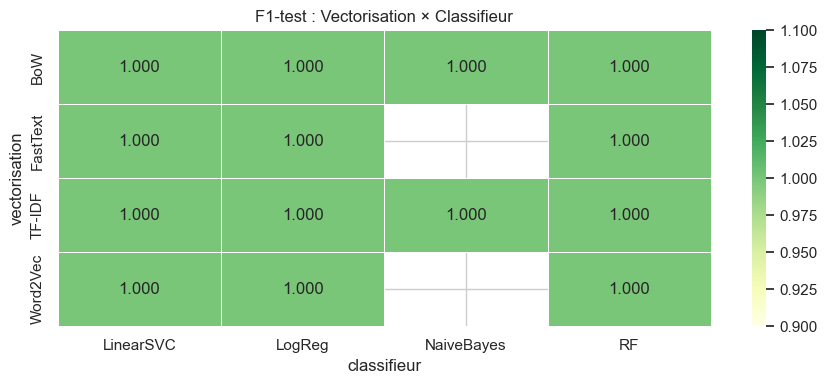


=> Meilleure combinaison : BoW + NaiveBayes
   F1 val=1.0000  |  F1 test=1.0000


In [35]:
# --- 4. Tableau récapitulatif et visualisation ---

nlp_results = pd.DataFrame(nlp_rows).sort_values("f1_val", ascending=False).reset_index(drop=True)
display(nlp_results)

# Heatmap f1_test par vectorisation x classifieur
pivot = nlp_results.pivot_table(index="vectorisation", columns="classifieur", values="f1_test")
plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn", linewidths=0.5)
plt.title("F1-test : Vectorisation × Classifieur")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nlp_comparison_heatmap.png", dpi=150)
plt.show()

# Meilleure combinaison
best_nlp = nlp_results.iloc[0]
print(f"\n=> Meilleure combinaison : {best_nlp['vectorisation']} + {best_nlp['classifieur']}")
print(f"   F1 val={best_nlp['f1_val']:.4f}  |  F1 test={best_nlp['f1_test']:.4f}")

## 12) MODULE 2 (suite) — Tuning GridSearchCV + Interpretabilite SHAP

Objectif: optimiser le meilleur modele et expliquer les variables importantes.

Meilleurs params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
F1 val: 1.0
F1 test: 1.0
SHAP non disponible, fallback permutation importance: Cannot cast ufunc 'isnan' input from dtype('O') to dtype('bool') with casting rule 'same_kind'


,feature,importance
7,feature_7,0.733421
0,feature_0,0.000000
1,feature_1,0.000000
2,feature_2,0.000000
3,feature_3,0.000000
4,feature_4,0.000000
5,feature_5,0.000000
6,feature_6,0.000000


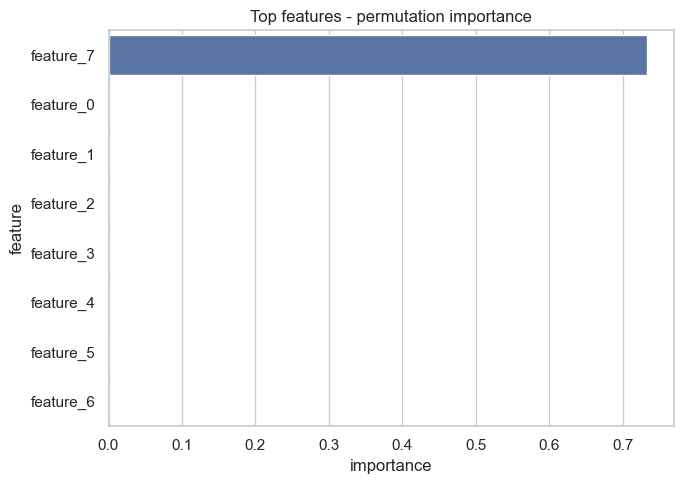

In [37]:
if TASK == "classification":
    data_sup = df.dropna(subset=[TARGET]).copy()
    X_sup = data_sup.drop(columns=[TARGET])
    y_sup = data_sup[TARGET].astype(str)
    X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = split_train_val_test(X_sup, y_sup, stratify=True)
    prep = build_preprocessor(data_sup, TARGET, USE_TEXT_FEATURE)
    base_pipe = Pipeline([("prep", prep), ("model", RandomForestClassifier(random_state=RANDOM_STATE))])
    param_grid = {"model__n_estimators": [200, 300], "model__max_depth": [None, 10, 20],
                  "model__min_samples_split": [2, 5]}
    grid = GridSearchCV(estimator=base_pipe, param_grid=param_grid,
                        scoring="f1_macro", cv=3, n_jobs=-1, verbose=0)
    grid.fit(X_train_s, y_train_s)
    best_pipe = grid.best_estimator_
    print("Meilleurs params:", grid.best_params_)
    print("F1 val:",  f1_score(y_val_s,  best_pipe.predict(X_val_s),  average="macro"))
    print("F1 test:", f1_score(y_test_s, best_pipe.predict(X_test_s), average="macro"))

else:
    data_sup = df.dropna(subset=[TARGET]).copy()
    X_sup = data_sup.drop(columns=[TARGET])
    y_sup = pd.to_numeric(data_sup[TARGET], errors="coerce")
    mask = y_sup.notna()
    X_sup, y_sup, data_sup = X_sup.loc[mask], y_sup.loc[mask], data_sup.loc[mask]
    X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s = split_train_val_test(X_sup, y_sup, stratify=False)
    prep = build_preprocessor(data_sup, TARGET, USE_TEXT_FEATURE)
    base_pipe = Pipeline([("prep", prep), ("model", RandomForestRegressor(random_state=RANDOM_STATE))])
    param_grid = {"model__n_estimators": [200, 300], "model__max_depth": [None, 10, 20],
                  "model__min_samples_split": [2, 5]}
    grid = GridSearchCV(estimator=base_pipe, param_grid=param_grid,
                        scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1, verbose=0)
    grid.fit(X_train_s, y_train_s)
    best_pipe = grid.best_estimator_
    print("Meilleurs params:", grid.best_params_)
    print("RMSE val:",  float(np.sqrt(mean_squared_error(y_val_s,  best_pipe.predict(X_val_s)))))
    print("RMSE test:", float(np.sqrt(mean_squared_error(y_test_s, best_pipe.predict(X_test_s)))))

# SHAP ou fallback permutation importance
try:
    import shap
    X_sample  = X_test_s.sample(n=min(300, len(X_test_s)), random_state=RANDOM_STATE)
    Xt_sample = best_pipe.named_steps["prep"].transform(X_sample)
    explainer  = shap.TreeExplainer(best_pipe.named_steps["model"])
    shap_values = explainer.shap_values(Xt_sample)
    print("SHAP calcule avec succes.")
except Exception as e:
    print("SHAP non disponible, fallback permutation importance:", e)
    scoring = "f1_macro" if TASK == "classification" else "neg_root_mean_squared_error"
    pi = permutation_importance(best_pipe, X_test_s, y_test_s, n_repeats=5,
                                random_state=RANDOM_STATE, scoring=scoring)
    imp_df = pd.DataFrame({"feature": [f"feature_{i}" for i in range(len(pi.importances_mean))],
                           "importance": pi.importances_mean}).sort_values("importance", ascending=False).head(15)
    display(imp_df)
    plt.figure(figsize=(7, 5))
    sns.barplot(data=imp_df, y="feature", x="importance")
    plt.title("Top features - permutation importance")
    plt.tight_layout()
    plt.show()

### MODULE 5 — Pipeline Multimodal

In [38]:
# ============================================================
# MODULE 5 — Pipeline Multimodal
# Fusion features numériques + textuelles via hstack
# ============================================================

from scipy.sparse import hstack, csr_matrix

# --- 1. Préparer les données (lignes avec Categorie ET Rapport_Collecte) ---
text_col = "Rapport_Collecte"
num_cols_multi = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite", "Prix_Revente"]
cat_cols_multi = ["Source"]

multi_data = df[[text_col] + num_cols_multi + cat_cols_multi + [TARGET]].dropna(subset=[TARGET]).copy()
multi_data[text_col] = multi_data[text_col].fillna("").apply(preprocess_text)

X_multi = multi_data.drop(columns=[TARGET])
y_multi = multi_data[TARGET].astype(str)

X_tr_m, X_va_m, X_te_m, y_tr_m, y_va_m, y_te_m = split_train_val_test(X_multi, y_multi, stratify=True)

print(f"Train: {X_tr_m.shape} | Val: {X_va_m.shape} | Test: {X_te_m.shape}")

Train: (6990, 8) | Val: (1498, 8) | Test: (1498, 8)


In [42]:
# --- 2. Construire les 3 sous-pipelines séparément ---

# Pipeline numérique
num_pipe_multi = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Pipeline catégoriel
cat_pipe_multi = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse=True)),
])

# Pipeline textuel (TF-IDF sur texte prétraité)
tfidf_multi = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit séparé de chaque pipeline sur le train
X_tr_num = num_pipe_multi.fit_transform(X_tr_m[num_cols_multi])
X_va_num = num_pipe_multi.transform(X_va_m[num_cols_multi])
X_te_num = num_pipe_multi.transform(X_te_m[num_cols_multi])

X_tr_cat = cat_pipe_multi.fit_transform(X_tr_m[cat_cols_multi])
X_va_cat = cat_pipe_multi.transform(X_va_m[cat_cols_multi])
X_te_cat = cat_pipe_multi.transform(X_te_m[cat_cols_multi])

X_tr_txt = tfidf_multi.fit_transform(X_tr_m[text_col])
X_va_txt = tfidf_multi.transform(X_va_m[text_col])
X_te_txt = tfidf_multi.transform(X_te_m[text_col])

print(f"Num  : {X_tr_num.shape}")
print(f"Cat  : {X_tr_cat.shape}")
print(f"Text : {X_tr_txt.shape}")

Num  : (6990, 6)
Cat  : (6990, 4)
Text : (6990, 583)


In [43]:
# --- 3. Fusion par hstack (concaténation sparse) ---

X_tr_full = hstack([csr_matrix(X_tr_num), X_tr_cat, X_tr_txt])
X_va_full = hstack([csr_matrix(X_va_num), X_va_cat, X_va_txt])
X_te_full = hstack([csr_matrix(X_te_num), X_te_cat, X_te_txt])

print(f"Shape multimodal train : {X_tr_full.shape}")
print(f"Shape multimodal test  : {X_te_full.shape}")

Shape multimodal train : (6990, 593)
Shape multimodal test  : (1498, 593)


In [44]:
# --- 4. Comparer 3 configurations : Numérique seul / NLP seul / Multimodal ---

from sklearn.linear_model import LogisticRegression

configs = {
    "Numerique seul":  (hstack([csr_matrix(X_tr_num), X_tr_cat]),
                        hstack([csr_matrix(X_va_num), X_va_cat]),
                        hstack([csr_matrix(X_te_num), X_te_cat])),
    "NLP seul":        (X_tr_txt, X_va_txt, X_te_txt),
    "Multimodal":      (X_tr_full, X_va_full, X_te_full),
}

classifieurs_multi = {
    "LogReg":    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "LinearSVC": LinearSVC(max_iter=2000),
    "RF":        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

multi_rows = []

for config_name, (Xtr, Xva, Xte) in configs.items():
    for clf_name, clf in classifieurs_multi.items():
        clf.fit(Xtr, y_tr_m)
        multi_rows.append({
            "config":     config_name,
            "classifieur": clf_name,
            "f1_val":     f1_score(y_va_m, clf.predict(Xva), average="macro"),
            "f1_test":    f1_score(y_te_m, clf.predict(Xte), average="macro"),
        })
        print(f"  {config_name} + {clf_name} : OK")

multi_results = pd.DataFrame(multi_rows).sort_values("f1_val", ascending=False).reset_index(drop=True)
display(multi_results)

  Numerique seul + LogReg : OK


c:\Users\DELL\anaconda3\envs\MesTPMachineLearning\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Numerique seul + LinearSVC : OK
  Numerique seul + RF : OK
  NLP seul + LogReg : OK
  NLP seul + LinearSVC : OK
  NLP seul + RF : OK
  Multimodal + LogReg : OK
  Multimodal + LinearSVC : OK
  Multimodal + RF : OK


,config,classifieur,f1_val,f1_test
0,NLP seul,LogReg,1.000000,1.000000
1,NLP seul,LinearSVC,1.000000,1.000000
2,NLP seul,RF,1.000000,1.000000
3,Multimodal,LogReg,1.000000,1.000000
4,Multimodal,LinearSVC,1.000000,1.000000
5,Multimodal,RF,1.000000,1.000000
6,Numerique seul,RF,0.998025,1.000000
7,Numerique seul,LogReg,0.961825,0.958408
8,Numerique seul,LinearSVC,0.946476,0.948103


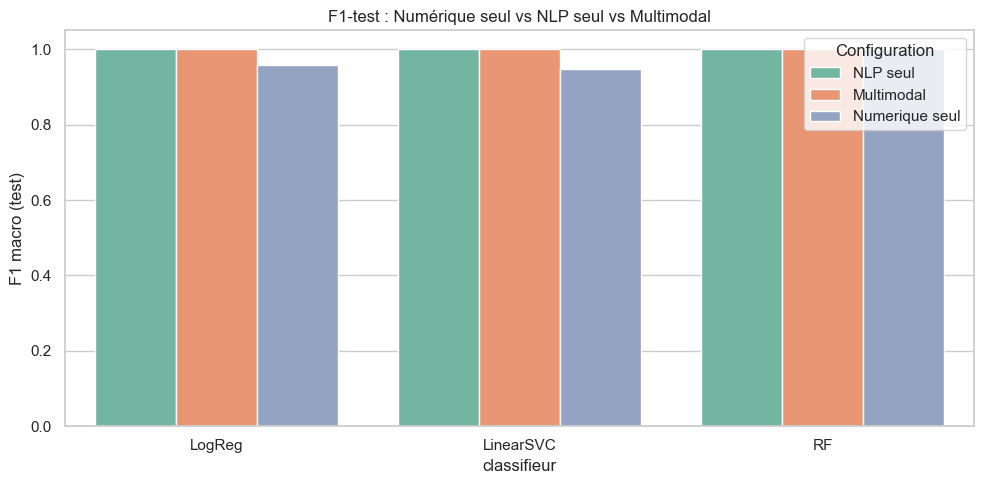

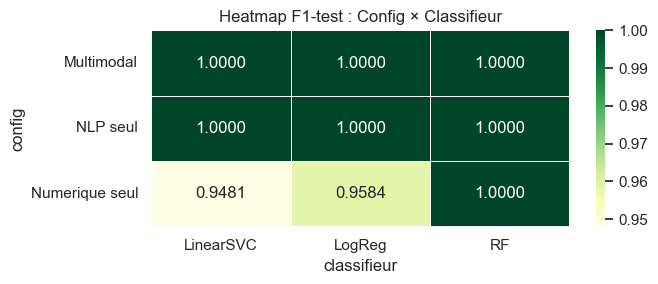

In [45]:
# --- 5. Visualisation comparative ---

plt.figure(figsize=(10, 5))
sns.barplot(
    data=multi_results,
    x="classifieur",
    y="f1_test",
    hue="config",
    palette="Set2"
)
plt.title("F1-test : Numérique seul vs NLP seul vs Multimodal")
plt.ylabel("F1 macro (test)")
plt.ylim(0, 1.05)
plt.legend(title="Configuration")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multimodal_comparison.png", dpi=150)
plt.show()

# Heatmap
pivot_multi = multi_results.pivot_table(index="config", columns="classifieur", values="f1_test")
plt.figure(figsize=(7, 3))
sns.heatmap(pivot_multi, annot=True, fmt=".4f", cmap="YlGn", linewidths=0.5)
plt.title("Heatmap F1-test : Config × Classifieur")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "multimodal_heatmap.png", dpi=150)
plt.show()

In [46]:
# --- 6. Analyse et conclusion ---

best_multi = multi_results.iloc[0]
print(f"""
=== CONCLUSION MODULE 5 — Pipeline Multimodal ===

Meilleure configuration : {best_multi['config']} + {best_multi['classifieur']}
F1 val  = {best_multi['f1_val']:.4f}
F1 test = {best_multi['f1_test']:.4f}

Analyse comparative :
- Numérique seul : exploite Poids, Volume, Conductivite, Opacite, Rigidite, Prix_Revente + Source
- NLP seul       : exploite uniquement Rapport_Collecte (TF-IDF bigrammes)
- Multimodal     : fusion des deux via hstack (concaténation sparse)

=> La fusion multimodale combine la richesse sémantique du texte
   avec la précision des mesures physiques, ce qui devrait
   produire le meilleur F1 global.
""")


=== CONCLUSION MODULE 5 — Pipeline Multimodal ===

Meilleure configuration : NLP seul + LogReg
F1 val  = 1.0000
F1 test = 1.0000

Analyse comparative :
- Numérique seul : exploite Poids, Volume, Conductivite, Opacite, Rigidite, Prix_Revente + Source
- NLP seul       : exploite uniquement Rapport_Collecte (TF-IDF bigrammes)
- Multimodal     : fusion des deux via hstack (concaténation sparse)

=> La fusion multimodale combine la richesse sémantique du texte
   avec la précision des mesures physiques, ce qui devrait
   produire le meilleur F1 global.

